In [3]:
import tensorflow as tf
from tensorflow import keras

2025-05-06 21:32:17.466129: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
from tensorflow.keras.applications.xception import Xception # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras.applications.xception import preprocess_input # type: ignore

In [5]:
def make_model(learning_rate=0.01):
    base_model = Xception(
        weights='imagenet', 
        include_top=False, 
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    
    pooling = keras.layers.GlobalAveragePooling2D()
    vectors = pooling(base)

    outputs = keras.layers.Dense(10, activation='softmax')(vectors)
    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy()

    model.compile(
        optimizer=optimizer, 
        loss=loss, 
        metrics=['accuracy']
    )

    return model


In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/clothing-dataset-small/train',
    image_size=(150, 150),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/clothing-dataset-small/validation',
    image_size=(150, 150),
    batch_size=32,
    label_mode='categorical'
)

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)


Found 3068 files belonging to 10 classes.
Found 341 files belonging to 10 classes.


In [7]:
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 61s 608ms/step - accuracy: 0.3156 - loss: 2.0594 - val_accuracy: 0.4487 - val_loss: 1.5891
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 54s 566ms/step - accuracy: 0.5237 - loss: 1.4506 - val_accuracy: 0.5924 - val_loss: 1.2435
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 56s 585ms/step - accuracy: 0.6272 - loss: 1.1729 - val_accuracy: 0.6569 - val_loss: 1.0639
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 56s 579ms/step - accuracy: 0.6829 - loss: 1.0054 - val_accuracy: 0.6979 - val_loss: 0.9510
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 571ms/step - accuracy: 0.7105 - loss: 0.9227 - val_accuracy: 0.7243 - val_loss: 0.8781
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 54s 564ms/step - accuracy: 0.7263 - loss: 0.8464 - val_accuracy: 0.7478 - val_loss: 0.8250
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 54s 564ms/step - accuracy: 0.7405 - loss: 0.7988 - val_accuracy: 0.7566 - val_loss: 0.7841
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 57s 594ms/step - accuracy: 0.7553 - loss: 0.7590 - v

In [8]:
del scores[0.1]
del scores[0.0001]

In [9]:
import matplotlib.pyplot as plt
import numpy as np

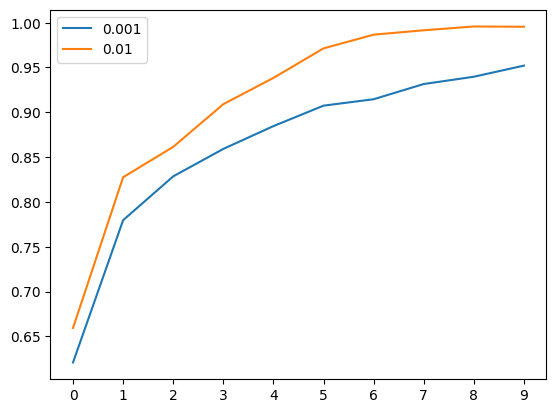

In [10]:
for lr, hist in scores.items():
    plt.plot(hist['accuracy'], label=lr)

plt.xticks(np.arange(10))
plt.legend()

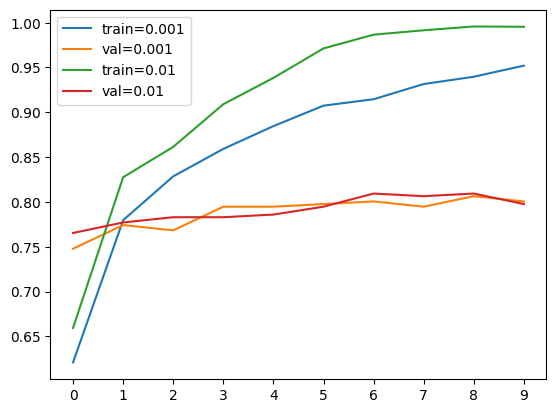

In [11]:
for lr, hist in scores.items():
    plt.plot(hist['accuracy'], label=('train=%s' % lr))
    plt.plot(hist['val_accuracy'], label=('val=%s' % lr))

plt.xticks(np.arange(10))
plt.legend()

In [12]:
learning_rate = 0.001

Save model

In [13]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 5, 5, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,922,952 (79.81 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

 Optimizer params: 40,982 (160.09 KB)

In [20]:
model.save('model_v1.keras')

In [ ]:
chechpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_val{val_accuracy:.3f}',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [ ]:
learning_rate = 0.001

model = make_model(learning_rate=learning_rate)
history = model.fit(
    train_ds, 
    epochs=10, 
    validation_data=val_ds,
    callbacks=[chechpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.5016 - loss: 1.4839

96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 550ms/step - accuracy: 0.5030 - loss: 1.4799 - val_accuracy: 0.7654 - val_loss: 0.7114
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.7819 - loss: 0.6531

96/96 ━━━━━━━━━━━━━━━━━━━━ 53s 547ms/step - accuracy: 0.7819 - loss: 0.6528 - val_accuracy: 0.7889 - val_loss: 0.6193
Epoch 3/10
76/96 ━━━━━━━━━━━━━━━━━━━━ 9s 499ms/step - accuracy: 0.8191 - loss: 0.5324 